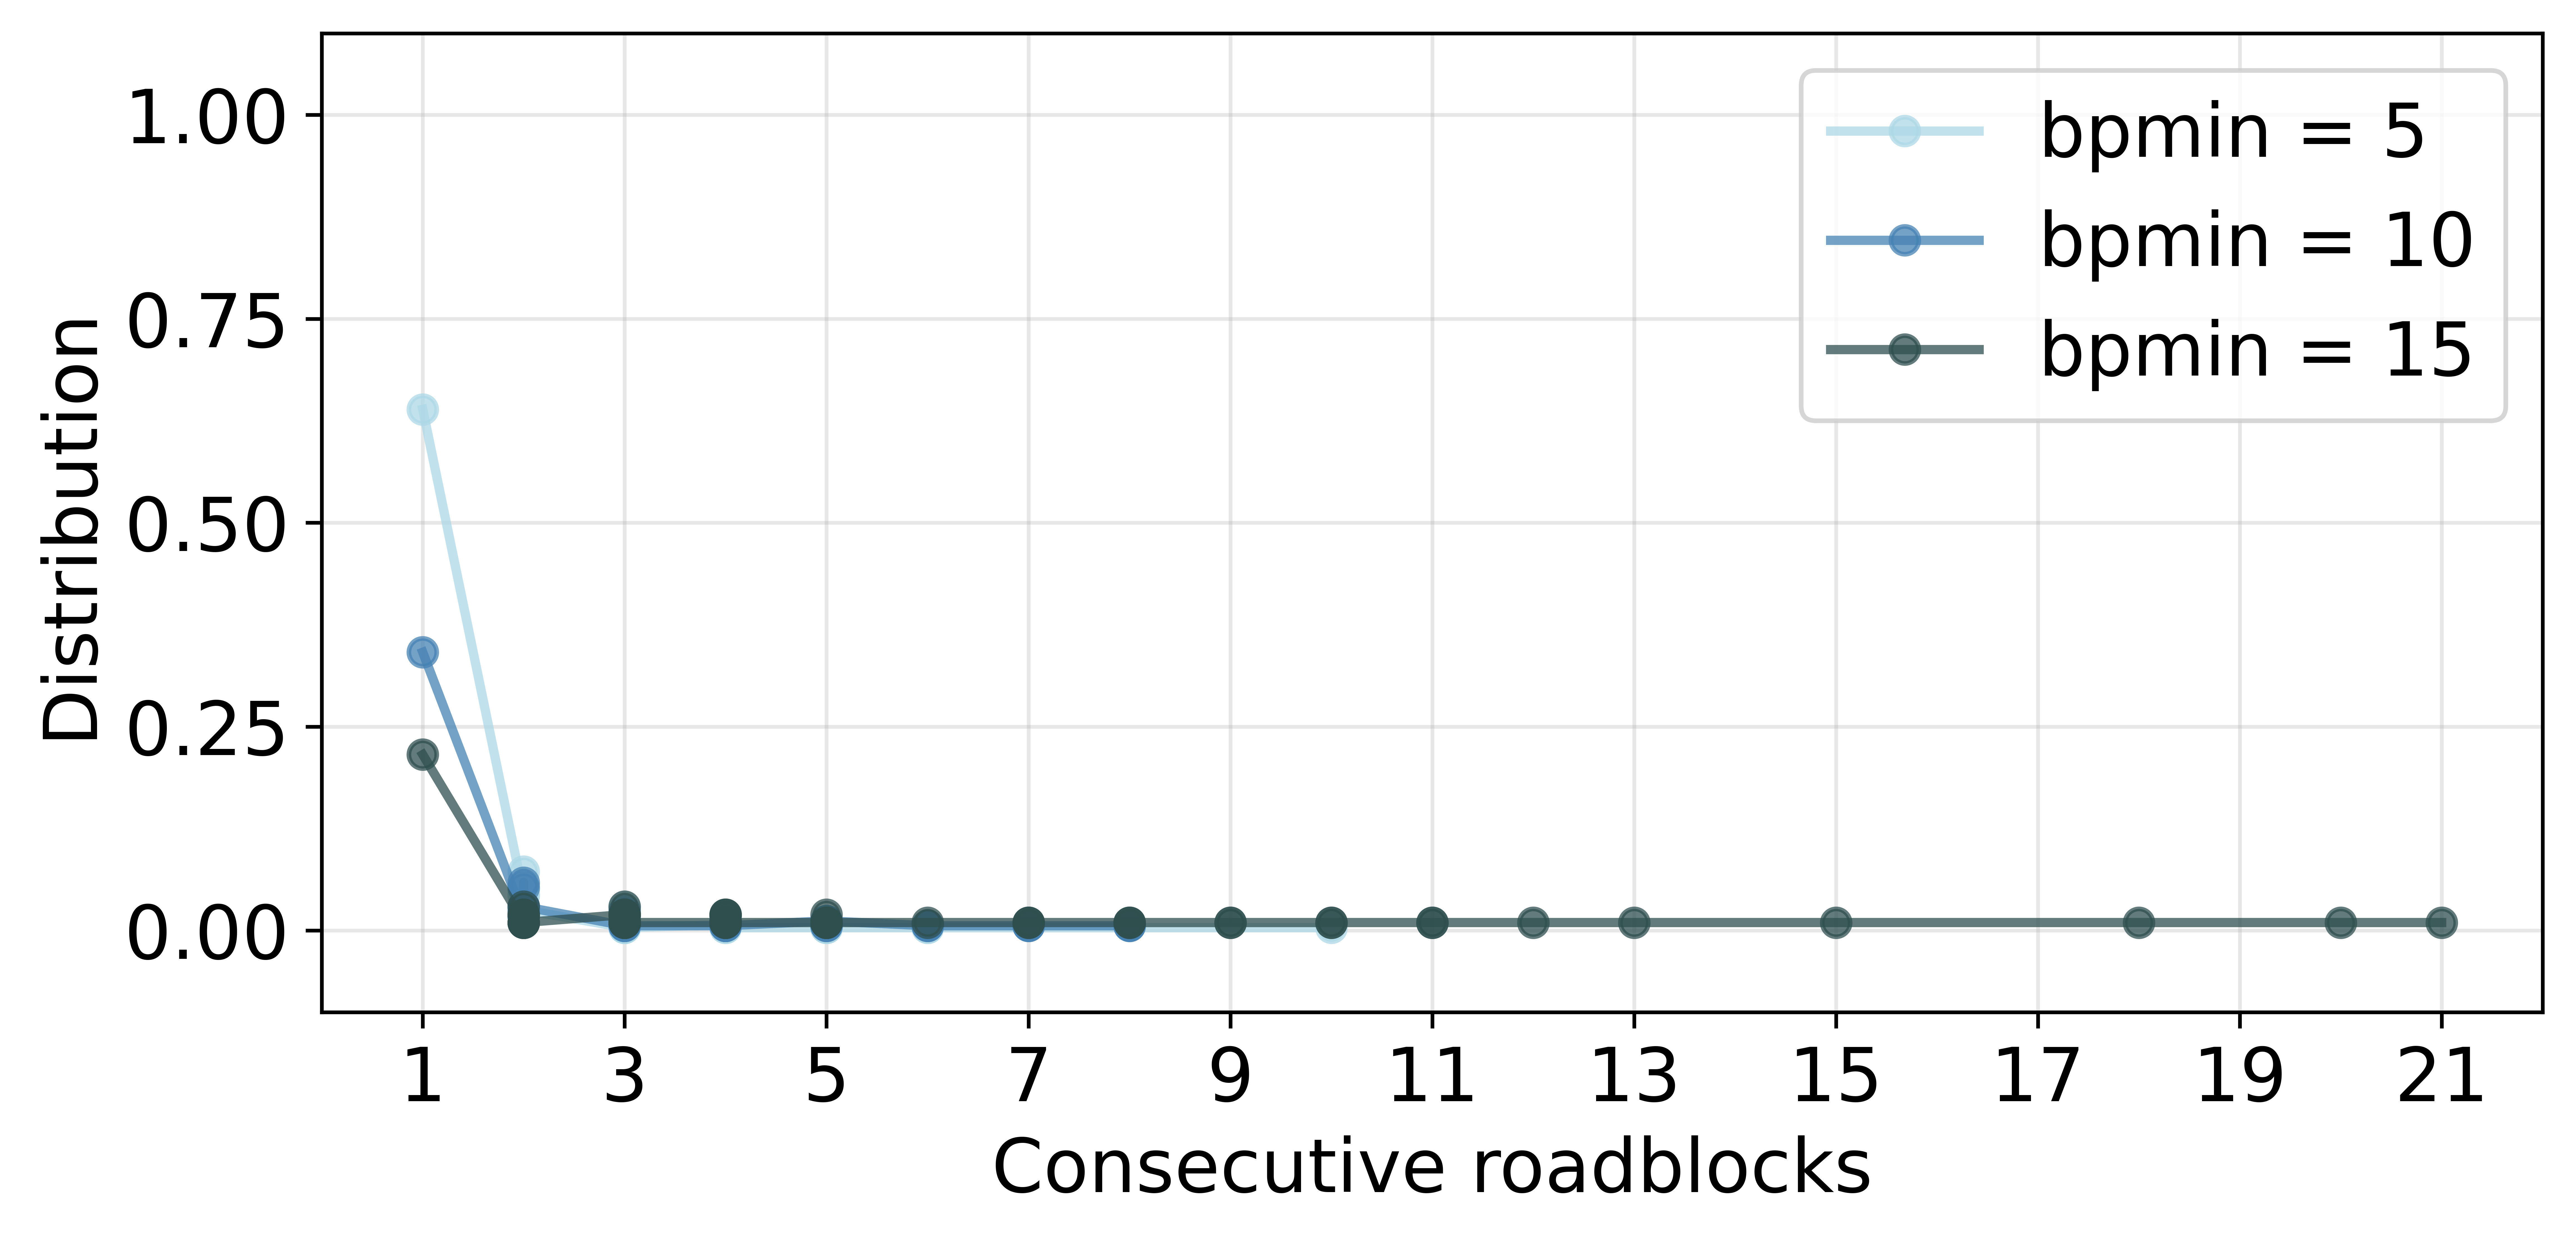

In [10]:
# Librairies
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from polars import selectors as cs
from pathlib import Path
from nucleo.metrics.utils import listoflist_into_matrix
plt.rcParams["font.size"] = 16

# Data
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURE_5__PC__2026-09-27/nucleo__fig5__0")
paths = [str(p) for p in root.rglob("*.parquet")]
df_sorted = (
    pl.scan_parquet(paths)
    .select(
        cs.string() | cs.boolean() | cs.integer() | cs.float() |
        pl.col("s_points") | pl.col("s_distrib") | pl.col("l_points") | pl.col("l_distrib")
    )
    .collect()
    .sort(by=["land", "bpmin"],
          descending=[False, False])
    .filter((pl.col("land") == "random") & (pl.col("l") == 10))
)

# Paramètres
s = 150
bpmins = [5, 10, 15]
colors = ["lightblue", "steelblue", "darkslategray"]

# Plot
plt.figure(figsize=(8, 4), dpi=1200)

for bp, color in zip(bpmins, colors):
    df_bp = df_sorted.filter(pl.col("bpmin") == bp)

    # Obstacles
    obs_points = np.nanmean(listoflist_into_matrix(df_bp["s_points"].to_list()), axis=0)
    obs_distrib = np.nanmean(listoflist_into_matrix(df_bp["s_distrib"].to_list()), axis=0)

    # To roadblocks
    mask_s = (obs_distrib != 0)
    roadblocks_points = obs_points[mask_s] // s
    roadblocks_distrib = obs_distrib[mask_s]

    plt.plot(roadblocks_points, roadblocks_distrib,
             label=f"bpmin = {bp}", color=color, alpha=0.75, marker="o", lw=2)

plt.xticks(np.arange(1, 22, 2, dtype=int))
plt.ylim([-0.10, 1.10])
plt.xlabel("Consecutive roadblocks")
plt.ylabel("Distribution")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()